# Preprocessing

### Outline
- Case Folding (Uppercase to Lowercase)
- Removing Noise (URLs, HTML tags, special characters, numbers)
- Tokenization
- Stopword Removal (before & after comparison)
- Lemmatization (root words / kata dasar)

## 1. Import Libraries & Load Data

In [ ]:
# Install required libraries (run once)
# !pip install pandas nltk sastrawi matplotlib seaborn wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Indonesian stemmer (for Bahasa Indonesia articles if applicable)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

print('All libraries loaded successfully.')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...


All libraries loaded successfully.


[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [168]:
df = pd.read_csv('../dataset/dataset.csv')

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded: 1001 rows, 4 columns
Columns: ['URL', 'Judul', 'Konten', 'Manual Sentiment']


,URL,Judul,Konten,Manual Sentiment
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive


## 2. Exploratory Data Analysis

### Basic Info & Missing Values

In [169]:
df.columns = df.columns.str.strip().str.lower()
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Shape: 1001 rows, 4 columns
<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   url               1001 non-null   str  
 1   judul             1001 non-null   str  
 2   konten            1001 non-null   str  
 3   manual sentiment  1001 non-null   str  
dtypes: str(4)
memory usage: 4.3 MB


In [170]:
# Missing values
display(pd.DataFrame({
    'Missing Count' : df.isna().sum(),
    'Missing %'     : (df.isna().sum() / len(df) * 100).round(2)
}))

,Missing Count,Missing %
url,0,0.0
judul,0,0.0
konten,0,0.0
manual sentiment,0,0.0


In [171]:
# Duplicate check
pd.DataFrame({
    'Check'  : ['Exact duplicates (by konten)'],
    'Count'  : [df.duplicated(subset=['konten']).sum()]
})

,Check,Count
0,Exact duplicates (by konten),2


In [172]:
df['manual sentiment'].value_counts()

manual sentiment
Negative    543
Netral      263
Positive    195
Name: count, dtype: int64

### Sentiment Distribution


In [173]:
dist_df = pd.DataFrame({
    'Count'      : df['manual sentiment'].value_counts(),
    'Percentage' : df['manual sentiment'].value_counts(normalize=True).mul(100).round(2)
})
display(dist_df)

,Count,Percentage
manual sentiment,,
Negative,543,54.25
Netral,263,26.27
Positive,195,19.48


### Article Source Distribution

In [174]:
from urllib.parse import urlparse

df['domain'] = df['url'].apply(lambda x: urlparse(x).netloc.replace('www.', ''))

In [175]:
# Top 15 domains
display(
    df['domain'].value_counts()
    .head(15)
    .rename_axis('Domain')
    .reset_index(name='Count')
)

,Domain,Count
0,cnbcindonesia.com,195
1,bloombergtechnoz.com,104
2,kompas.id,91
3,metrotvnews.com,60
4,tempo.co,58
5,cnnindonesia.com,54
6,news.detik.com,40
7,money.kompas.com,38
8,finance.detik.com,27
9,antaranews.com,24


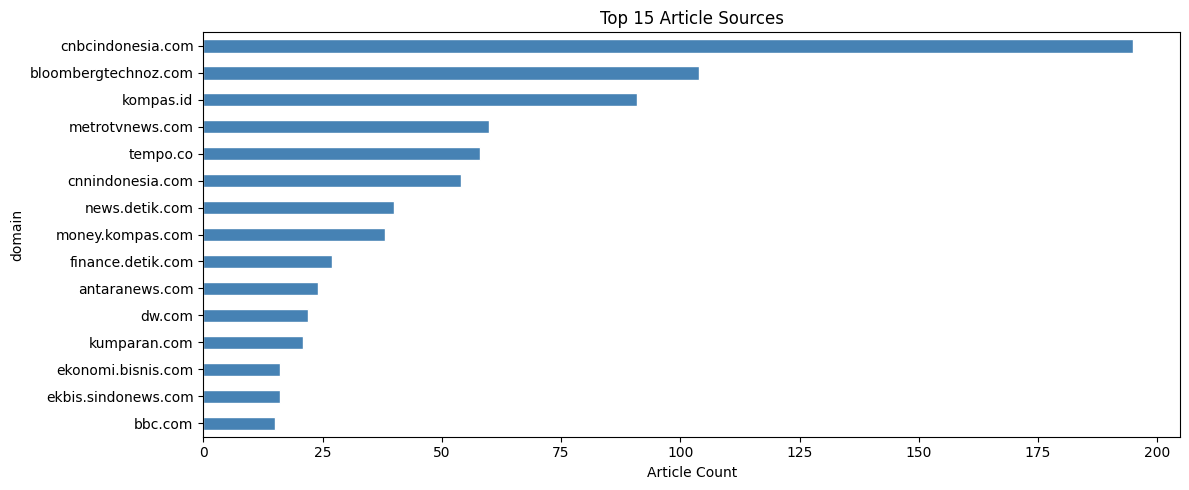

In [176]:
top_domains = df['domain'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top_domains.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Article Sources')
ax.set_xlabel('Article Count')
plt.tight_layout()
plt.show()

In [177]:
domain = df['domain'].unique()
domain

<ArrowStringArray>
[          'cnbcindonesia.com',                 'indodax.com',
   'bpjsketenagakerjaan.go.id',       'infografik.bisnis.com',
                  'niaga.asia',              'antaranews.com',
          'muhammadiyah.or.id',          'kabar24.bisnis.com',
           'market.bisnis.com',        'jatim.antaranews.com',
 ...
 'international.sindonews.com',             'etindonesia.com',
       'radarseluma.disway.id',              'kompasiana.com',
                  'pantau.com',         'editorindonesia.com',
          'mediaindonesia.com',             'news.ddtc.co.id',
              'idxchannel.com',         'agroindonesia.co.id']
Length: 109, dtype: str

## 3. Data Cleaning

In [178]:
before = len(df)
df = df.drop_duplicates(subset=['konten'], keep='first').reset_index(drop=True)
after = len(df)

display(pd.DataFrame([
    {'Step': 'Before deduplication', 'Count': before},
    {'Step': 'After deduplication',  'Count': after},
    {'Step': 'Removed',              'Count': before - after},
]).set_index('Step'))

,Count
Step,
Before deduplication,1001
After deduplication,999
Removed,2


## 4. Text Preprocessing Pipeline

The preprocessing pipeline includes:
1. Case folding (uppercase to lowercase)
2. Noise removal (URLs, HTML tags, special characters, extra whitespace)
3. Tokenization
4. Stopword removal
5. Lemmatization

In [179]:
import re

def fix_merged_words(text):
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    text = re.sub(r'(\d)([A-Za-z])', r'\1 \2', text)
    text = re.sub(r'([A-Za-z])(\d)', r'\1 \2', text)

    return text

df['konten_clean'] = df['konten'].astype(str).apply(fix_merged_words)

### 4.1 Case Folding (Uppercase to Lowercase)

In [180]:
df['konten_clean'] = df['konten'].astype(str).str.lower()

df[['konten', 'konten_clean']].head(3)

,konten,konten_clean
0,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...","jakarta, cnbc indonesia -amerika serikat (as) ..."
1,"Jakarta, CNBC Indonesia -Nilai tukar rupiah te...","jakarta, cnbc indonesia -nilai tukar rupiah te..."
2,"Jakarta, CNBC Indonesia-Pasar keuangan Indones...","jakarta, cnbc indonesia-pasar keuangan indones..."


### 4.2 Noise Removal

In [181]:
def remove_noise(text):
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove mentions
    text = re.sub(r'@\w+', ' ', text)

    # Remove hashtag symbol (keep the word)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove single characters (except 'a' and 'i' for English)
    text = re.sub(r'\b[b-hj-z]\b', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['konten_clean'] = df['konten_clean'].apply(remove_noise)

print('Noise removal completed.')
print('\nSample result:')
print(df['konten_clean'].iloc[0][:300])

Noise removal completed.

Sample result:
jakarta cnbc indonesia amerika serikat as secara resmi memiliki presiden baru yang disambut positif karena agenda pro bisnis yang dibawanya presiden amerika serikat as donald trump resmi dilantik pada senin waktu as secara umum dalam pidatonya trump mengungkapkan kebijakan perdagangan proteksionis y


### 4.3 Tokenization

In [182]:
from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer(r'\w+')
df['tokens'] = df['konten_clean'].apply(tokenizer.tokenize)
df['n_tokens'] = df['tokens'].apply(len)

df.head(5)

,url,judul,konten,manual sentiment,domain,konten_clean,tokens,n_tokens
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,cnbcindonesia.com,jakarta cnbc indonesia amerika serikat as seca...,"[jakarta, cnbc, indonesia, amerika, serikat, a...",1104
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,cnbcindonesia.com,jakarta cnbc indonesia nilai tukar rupiah terh...,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",387
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,cnbcindonesia.com,jakarta cnbc indonesia pasar keuangan indonesi...,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",1699
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,cnbcindonesia.com,jakarta cnbc indonesia indeks harga saham gabu...,"[jakarta, cnbc, indonesia, indeks, harga, saha...",694
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,indodax.com,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, pernah, melewati, angka, t...",632


### 4.4 Stopword Removal

In [183]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stop_words_id_nltk     = set(stopwords.words('indonesian'))
stop_words_id_sastrawi = set(StopWordRemoverFactory().get_stop_words())
stop_words_en          = set(stopwords.words('english'))

custom_stopwords = {
    # sumber berita
    'reuters', 'ap', 'afp', 'kompas', 'detik', 'cnbc', 'cnn', 'bbc', 'liputan',
    # nama yang muncul di semua artikel (tidak diskriminatif)
    'indonesia', 'trump', 'donald', 'amerika', 'serikat', 'as', 'washington',
    'jakarta', 'jakarta',
    # kata umum artikel berita
    'foto', 'baca', 'juga', 'berita', 'read', 'more', 'click',
    'share', 'comment', 'subscribe',
}

combined_stopwords = stop_words_id_nltk | stop_words_id_sastrawi | stop_words_en | custom_stopwords

display(pd.DataFrame([
    {'Source': 'Indonesian - NLTK',     'Count': len(stop_words_id_nltk)},
    {'Source': 'Indonesian - Sastrawi', 'Count': len(stop_words_id_sastrawi)},
    {'Source': 'English - NLTK',        'Count': len(stop_words_en)},
    {'Source': 'Custom',                'Count': len(custom_stopwords)},
    {'Source': 'Total combined',        'Count': len(combined_stopwords)},
]).set_index('Source'))

,Count
Source,
Indonesian - NLTK,757
Indonesian - Sastrawi,123
English - NLTK,198
Custom,27
Total combined,996


In [184]:
df

,url,judul,konten,manual sentiment,domain,konten_clean,tokens,n_tokens
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,cnbcindonesia.com,jakarta cnbc indonesia amerika serikat as seca...,"[jakarta, cnbc, indonesia, amerika, serikat, a...",1104
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,cnbcindonesia.com,jakarta cnbc indonesia nilai tukar rupiah terh...,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",387
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,cnbcindonesia.com,jakarta cnbc indonesia pasar keuangan indonesi...,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",1699
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,cnbcindonesia.com,jakarta cnbc indonesia indeks harga saham gabu...,"[jakarta, cnbc, indonesia, indeks, harga, saha...",694
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,indodax.com,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, pernah, melewati, angka, t...",632
...,...,...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,voi.id,jakarta tiga produsen mesin penambang bitcoin ...,"[jakarta, tiga, produsen, mesin, penambang, bi...",499
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,liputan6.com,presiden amerika serikat as donald trump menga...,"[presiden, amerika, serikat, as, donald, trump...",448
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,kabar24.bisnis.com,bisnis com jakarta serangan amerika serikat as...,"[bisnis, com, jakarta, serangan, amerika, seri...",632
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,cnbcindonesia.com,jakarta cnbc indonesia perusahaan semikondukto...,"[jakarta, cnbc, indonesia, perusahaan, semikon...",386


In [185]:
df['tokens_no_sw'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in combined_stopwords]
)

df['n_tokens_no_sw'] = df['tokens_no_sw'].apply(len)

# Before vs after comparison
display(pd.DataFrame({
    'Before stopwords': df['n_tokens'].describe(),
    'After stopwords' : df['n_tokens_no_sw'].describe(),
}).round(2))

,Before stopwords,After stopwords
count,999.00,999.00
mean,574.21,314.10
std,546.95,305.45
min,18.00,12.00
25%,252.00,131.00
50%,382.00,204.00
75%,683.50,369.50
max,3573.00,1953.00


In [186]:
df

,url,judul,konten,manual sentiment,domain,konten_clean,tokens,n_tokens,tokens_no_sw,n_tokens_no_sw
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,cnbcindonesia.com,jakarta cnbc indonesia amerika serikat as seca...,"[jakarta, cnbc, indonesia, amerika, serikat, a...",1104,"[resmi, memiliki, presiden, disambut, positif,...",558
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,cnbcindonesia.com,jakarta cnbc indonesia nilai tukar rupiah terh...,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",387,"[nilai, tukar, rupiah, dolar, menguat, dilanti...",195
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,cnbcindonesia.com,jakarta cnbc indonesia pasar keuangan indonesi...,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",1699,"[pasar, keuangan, menguat, pelantikan, preside...",982
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,cnbcindonesia.com,jakarta cnbc indonesia indeks harga saham gabu...,"[jakarta, cnbc, indonesia, indeks, harga, saha...",694,"[indeks, harga, saham, gabungan, ihsg, ambruk,...",392
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,indodax.com,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, pernah, melewati, angka, t...",632,"[hargabitcoin, btc, melewati, angka, tertinggi...",337
...,...,...,...,...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,voi.id,jakarta tiga produsen mesin penambang bitcoin ...,"[jakarta, tiga, produsen, mesin, penambang, bi...",499,"[produsen, mesin, penambang, bitcoin, terbesar...",287
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,liputan6.com,presiden amerika serikat as donald trump menga...,"[presiden, amerika, serikat, as, donald, trump...",448,"[presiden, mengaku, serangannya, mempersulit, ...",224
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,kabar24.bisnis.com,bisnis com jakarta serangan amerika serikat as...,"[bisnis, com, jakarta, serangan, amerika, seri...",632,"[bisnis, com, serangan, fasilitas, nuklir, uta...",373
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,cnbcindonesia.com,jakarta cnbc indonesia perusahaan semikondukto...,"[jakarta, cnbc, indonesia, perusahaan, semikon...",386,"[perusahaan, semikonduktor, texas, instruments...",211


### 4.5 Stemming

In [187]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

df['tokens_stemmed'] = df['tokens_no_sw'].apply(stem_tokens)
df['konten_preprocessed'] = df['tokens_stemmed'].apply(lambda x: ' '.join(x))

df[['judul', 'manual sentiment', 'tokens_no_sw', 'tokens_stemmed', 'konten_preprocessed']].head(5)

,judul,manual sentiment,tokens_no_sw,tokens_stemmed,konten_preprocessed
0,Trump Sebar Exceutive Order: Emang Semengerika...,Positive,"[resmi, memiliki, presiden, disambut, positif,...","[resmi, milik, presiden, sambut, positif, agen...",resmi milik presiden sambut positif agenda pro...
1,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...",Positive,"[nilai, tukar, rupiah, dolar, menguat, dilanti...","[nilai, tukar, rupiah, dolar, kuat, lantik, pr...",nilai tukar rupiah dolar kuat lantik presiden ...
2,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...",Positive,"[pasar, keuangan, menguat, pelantikan, preside...","[pasar, uang, kuat, lantik, presiden, indeks, ...",pasar uang kuat lantik presiden indeks harga s...
3,"IHSG Merah Lagi, Begini Penjelasan dari Analis...",Negative,"[indeks, harga, saham, gabungan, ihsg, ambruk,...","[indeks, harga, saham, gabung, ihsg, ambruk, l...",indeks harga saham gabung ihsg ambruk level pu...
4,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,Positive,"[hargabitcoin, btc, melewati, angka, tertinggi...","[hargabitcoin, btc, lewat, angka, tinggi, kisa...",hargabitcoin btc lewat angka tinggi kisara pic...


## 5. Word Frequency Analysis

In [188]:
all_tokens = [token for tokens in df['tokens_stemmed'] for token in tokens]
word_freq  = Counter(all_tokens)

top_50_df = (
    pd.DataFrame(word_freq.most_common(50), columns=['Word', 'Frequency'])
    .rename_axis('Rank')
)
top_50_df.index += 1

display(top_50_df)

,Word,Frequency
Rank,,
1,tarif,10172
2,negara,5911
3,dagang,5295
4,china,3808
5,persen,3445
6,impor,3288
7,ekonomi,3123
8,bijak,3101
9,produk,2569


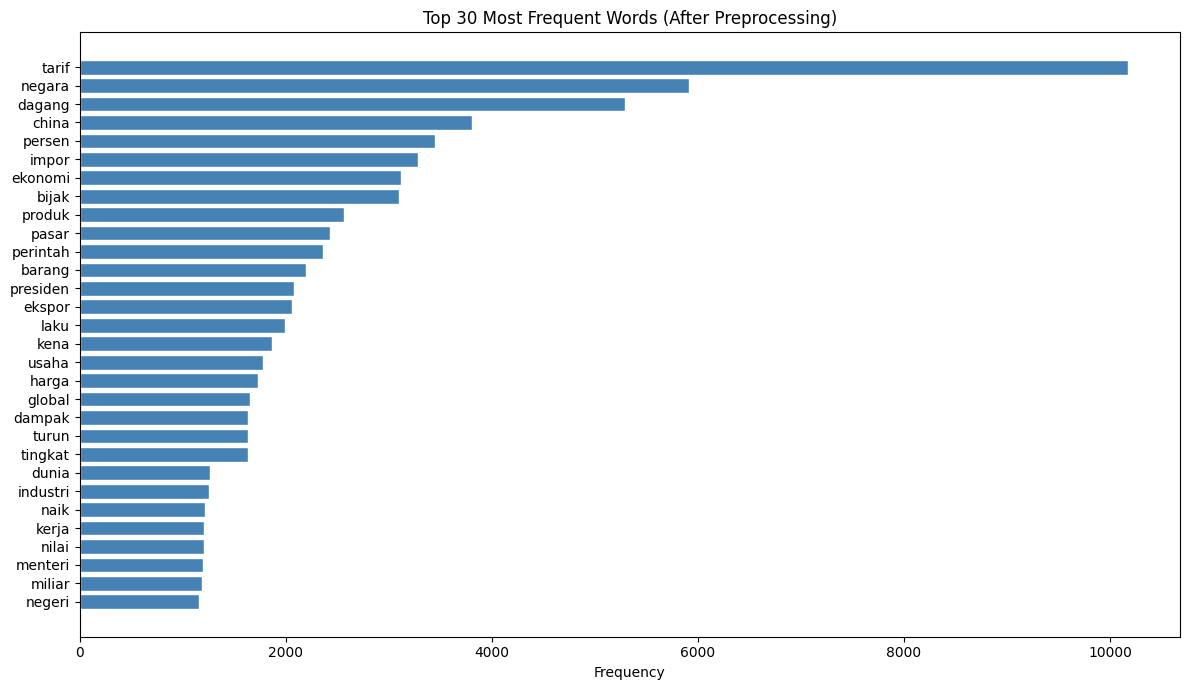

In [189]:
top_30 = top_50_df.head(30)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_30['Word'], top_30['Frequency'], color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 30 Most Frequent Words (After Preprocessing)')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

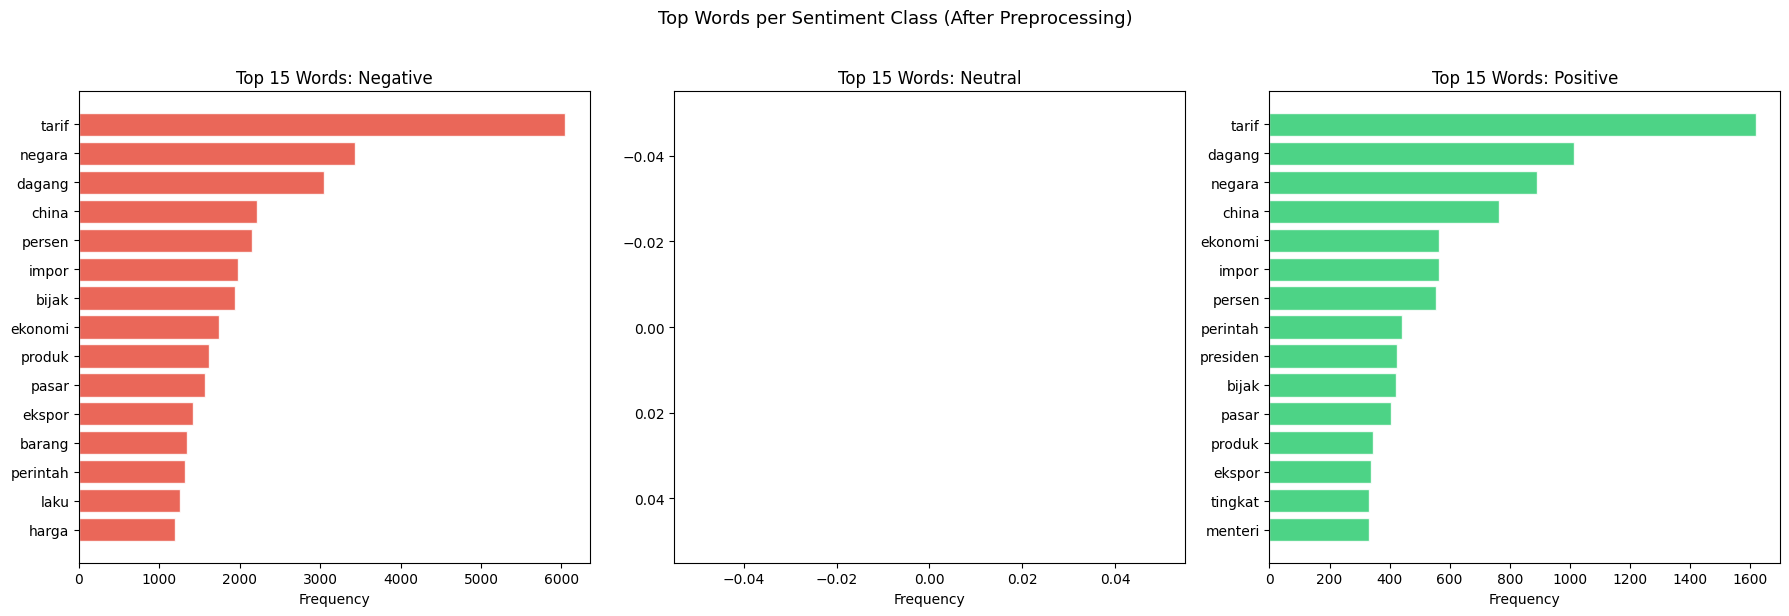

In [190]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (sentiment, color) in zip(axes, [
    ('Negative', '#e74c3c'),
    ('Neutral',  '#95a5a6'),
    ('Positive', '#2ecc71')
]):
    tokens_class = [
        token
        for tokens in df[df['manual sentiment'] == sentiment]['tokens_stemmed']
        for token in tokens
    ]
    top15 = pd.DataFrame(Counter(tokens_class).most_common(15), columns=['Word', 'Freq'])

    ax.barh(top15['Word'], top15['Freq'], color=color, edgecolor='white', alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Words: {sentiment}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top Words per Sentiment Class (After Preprocessing)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

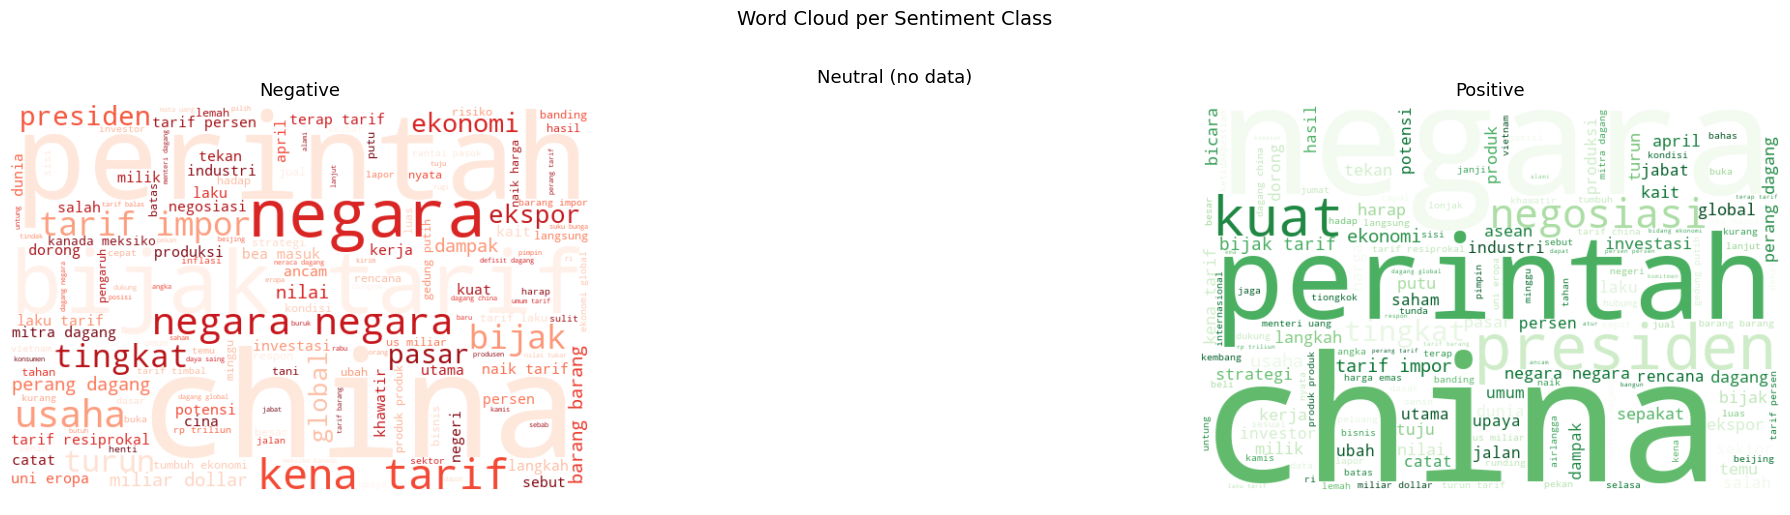

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (sentiment, cmap) in zip(axes, [
    ('Negative', 'Reds'),
    ('Neutral',  'Greys'),
    ('Positive', 'Greens')
]):
    text_class = ' '.join([
        token
        for tokens in df[df['manual sentiment'] == sentiment]['tokens_stemmed']
        for token in tokens
    ]).strip()

    if not text_class:
        ax.axis('off')
        ax.set_title(f'{sentiment} (no data)', fontsize=13)
        continue

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        max_words=150,
        colormap=cmap,
        random_state=42
    ).generate(text_class)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment}', fontsize=13)

plt.suptitle('Word Cloud per Sentiment Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [193]:
df

,url,judul,konten,manual sentiment,domain,konten_clean,tokens,n_tokens,tokens_no_sw,n_tokens_no_sw,tokens_stemmed,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,cnbcindonesia.com,jakarta cnbc indonesia amerika serikat as seca...,"[jakarta, cnbc, indonesia, amerika, serikat, a...",1104,"[resmi, memiliki, presiden, disambut, positif,...",558,"[resmi, milik, presiden, sambut, positif, agen...",resmi milik presiden sambut positif agenda pro...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,cnbcindonesia.com,jakarta cnbc indonesia nilai tukar rupiah terh...,"[jakarta, cnbc, indonesia, nilai, tukar, rupia...",387,"[nilai, tukar, rupiah, dolar, menguat, dilanti...",195,"[nilai, tukar, rupiah, dolar, kuat, lantik, pr...",nilai tukar rupiah dolar kuat lantik presiden ...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,cnbcindonesia.com,jakarta cnbc indonesia pasar keuangan indonesi...,"[jakarta, cnbc, indonesia, pasar, keuangan, in...",1699,"[pasar, keuangan, menguat, pelantikan, preside...",982,"[pasar, uang, kuat, lantik, presiden, indeks, ...",pasar uang kuat lantik presiden indeks harga s...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,cnbcindonesia.com,jakarta cnbc indonesia indeks harga saham gabu...,"[jakarta, cnbc, indonesia, indeks, harga, saha...",694,"[indeks, harga, saham, gabungan, ihsg, ambruk,...",392,"[indeks, harga, saham, gabung, ihsg, ambruk, l...",indeks harga saham gabung ihsg ambruk level pu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,indodax.com,hargabitcoin btc pernah melewati angka terting...,"[hargabitcoin, btc, pernah, melewati, angka, t...",632,"[hargabitcoin, btc, melewati, angka, tertinggi...",337,"[hargabitcoin, btc, lewat, angka, tinggi, kisa...",hargabitcoin btc lewat angka tinggi kisara pic...
...,...,...,...,...,...,...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,voi.id,jakarta tiga produsen mesin penambang bitcoin ...,"[jakarta, tiga, produsen, mesin, penambang, bi...",499,"[produsen, mesin, penambang, bitcoin, terbesar...",287,"[produsen, mesin, tambang, bitcoin, besar, dun...",produsen mesin tambang bitcoin besar dunia chi...
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,liputan6.com,presiden amerika serikat as donald trump menga...,"[presiden, amerika, serikat, as, donald, trump...",448,"[presiden, mengaku, serangannya, mempersulit, ...",224,"[presiden, aku, serang, sulit, langkah, ketua,...",presiden aku serang sulit langkah ketua fed je...
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,kabar24.bisnis.com,bisnis com jakarta serangan amerika serikat as...,"[bisnis, com, jakarta, serangan, amerika, seri...",632,"[bisnis, com, serangan, fasilitas, nuklir, uta...",373,"[bisnis, com, serang, fasilitas, nuklir, utama...",bisnis com serang fasilitas nuklir utama iran ...
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,cnbcindonesia.com,jakarta cnbc indonesia perusahaan semikondukto...,"[jakarta, cnbc, indonesia, perusa

## 7. Export Preprocessed Dataset

In [195]:
export_cols = ['url', 'judul', 'konten', 'manual sentiment', 'konten_preprocessed']
df_export = df[export_cols].copy()

df_export.head()

,url,judul,konten,manual sentiment,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,resmi milik presiden sambut positif agenda pro...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,nilai tukar rupiah dolar kuat lantik presiden ...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,pasar uang kuat lantik presiden indeks harga s...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,indeks harga saham gabung ihsg ambruk level pu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,hargabitcoin btc lewat angka tinggi kisara pic...


In [196]:
df_export.to_csv('../outputs/dataset_preprocessed_razan.csv', index=False, encoding='utf-8')
print('Export selesai.')

df_export

Export selesai.


,url,judul,konten,manual sentiment,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,resmi milik presiden sambut positif agenda pro...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,nilai tukar rupiah dolar kuat lantik presiden ...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,pasar uang kuat lantik presiden indeks harga s...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,indeks harga saham gabung ihsg ambruk level pu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,hargabitcoin btc lewat angka tinggi kisara pic...
...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,produsen mesin tambang bitcoin besar dunia chi...
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,presiden aku serang sulit langkah ketua fed je...
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,bisnis com serang fasilitas nuklir utama iran ...
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,usaha semikonduktor texas instruments ti umum ...
